In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

In [2]:
# --- Load the cleaned and transformed dataset ---
df = pd.read_csv("merged_data.csv")
df.head()

,realSum,logSum,room_type_apt,room_type_private,room_type_shared,person_capacity,is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,rest_index,city,is_weekday
0,194.033698,5.268032,0,1,0,2.0,0,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,98.253896,Amsterdam,1
1,344.245776,5.841356,0,1,0,4.0,0,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,837.280757,Amsterdam,1
2,264.101422,5.576333,0,1,0,2.0,0,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,95.386955,Amsterdam,1
3,433.529398,6.071960,0,1,0,4.0,0,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,875.033098,Amsterdam,1
4,485.552926,6.185288,0,1,0,2.0,1,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,815.305740,Amsterdam,1


In [3]:
# Column definitions

numeric_cols = [
    "cleanliness_rating",
    "guest_satisfaction_overall",
    "person_capacity", 
    "bedrooms", 
    "dist", 
    "metro_dist",
    "attr_index", 
    "rest_index"]

binary_cols = [
    "room_type_apt", 
    "room_type_private",
    "is_superhost", 
    "multi", 
    "biz", 
    "is_weekday"]

categorical_cols = ["city"]

target_col = "logSum"

raw_feature_cols = numeric_cols + binary_cols + categorical_cols

X = df[raw_feature_cols].copy()
y = df[target_col].copy()

In [4]:
preprocess = ColumnTransformer(
    transformers=[
        ("scale_numeric", StandardScaler(), numeric_cols),

        ("binary", "passthrough", binary_cols),

        ("city_dummies", OneHotEncoder(
            drop="first", 
            handle_unknown="ignore", 
            sparse_output=False
            ), categorical_cols),
    ],
    remainder="drop",
)

preprocess.fit(X)

city_dummy_cols = list(
    preprocess.named_transformers_["city_dummies"].get_feature_names_out(categorical_cols)
)

all_feature_cols = numeric_cols + binary_cols + city_dummy_cols

X_processed = pd.DataFrame(
    preprocess.transform(X), columns=all_feature_cols, index=X.index,
)

In [5]:
X_processed.head()

,cleanliness_rating,guest_satisfaction_overall,person_capacity,bedrooms,dist,metro_dist,attr_index,rest_index,room_type_apt,room_type_private,...,is_weekday,city_Athens,city_Barcelona,city_Berlin,city_Budapest,city_Lisbon,city_London,city_Paris,city_Rome,city_Vienna
0,0.640171,0.044027,-0.889287,-0.241320,0.761648,2.155330,-0.956307,-1.058388,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.456353,-0.850966,0.659044,-0.241320,-1.129569,-0.515882,1.515708,0.427149,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.408091,-0.627218,-0.889287,-0.241320,1.064166,3.447096,-0.971585,-1.064151,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.408091,-0.291595,0.659044,1.382141,-1.172747,-0.283052,0.898678,0.503036,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.640171,0.603398,-0.889287,-0.241320,-1.106068,-0.423796,1.165160,0.382976,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


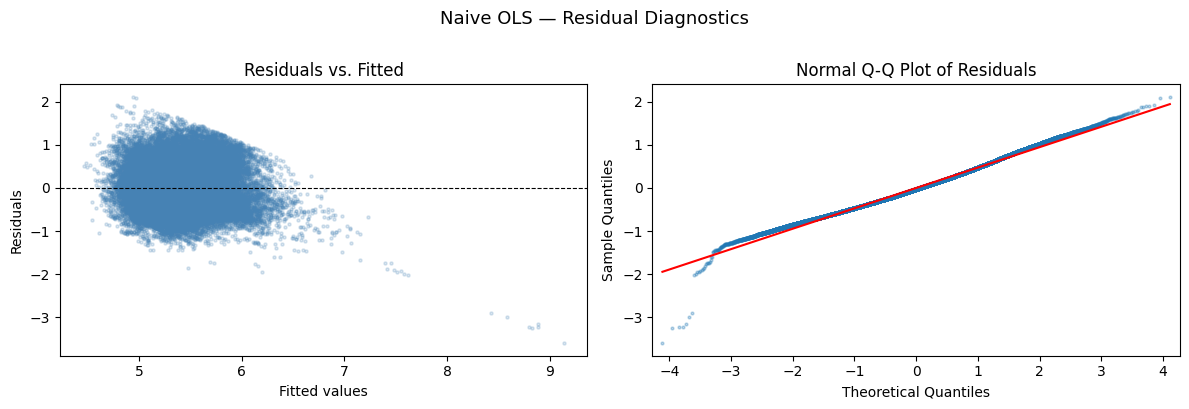

In [6]:
# --- Naive Multiple Linear Regression Baseline ---

# Target : logSum
# Features: city dummy excluded
# room_type_shared as the reference category

naive_feature_cols = [
    "cleanliness_rating", "guest_satisfaction_overall",
    "person_capacity", "bedrooms", 
    "dist", "metro_dist",
    "attr_index", "rest_index",
    "room_type_apt", "room_type_private",
    "is_superhost", "multi", "biz",
    "is_weekday"
]

X_naive = X_processed[naive_feature_cols].copy()

X_naive_const = sm.add_constant(X_naive)
model_naive = sm.OLS(y, X_naive_const).fit()

# --- VIF to quantify multicollinearity ---
vif_data = {
    "Feature": naive_feature_cols,
    "VIF": [variance_inflation_factor(X_naive_const.values, i) for i in range(1, X_naive_const.shape[1])],
}

vif_df = (
    pd.DataFrame(vif_data)
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

# --- Residual diagnostics ---
fitted = model_naive.fittedvalues
residuals = model_naive.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted, residuals, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

sm.qqplot(residuals, line="s", ax=axes[1], alpha=0.3, markersize=2)
axes[1].set_title("Normal Q-Q Plot of Residuals")

plt.suptitle("Naive OLS — Residual Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("plots/section3_PlotDiagnostics1_naiveOLS.png", dpi=300, bbox_inches="tight")
plt.show()


In [7]:
print("=== NAIVE OLS MODEL COEFFICIENTS ===")
print(model_naive.summary().tables[1])

=== NAIVE OLS MODEL COEFFICIENTS ===
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          4.9420      0.025    196.198      0.000       4.893       4.991
cleanliness_rating             0.0144      0.003      4.787      0.000       0.009       0.020
guest_satisfaction_overall    -0.0042      0.003     -1.374      0.170      -0.010       0.002
person_capacity                0.0569      0.003     19.203      0.000       0.051       0.063
bedrooms                       0.0846      0.003     32.739      0.000       0.079       0.090
dist                           0.1101      0.003     39.728      0.000       0.105       0.115
metro_dist                    -0.0729      0.003    -28.679      0.000      -0.078      -0.068
attr_index                     0.1850      0.004     45.799      0.000       0.177       0.193
rest_index   

In [8]:
print("=== NAIVE OLS MODEL VARIANCE INFLATION FACTORS ===")
vif_df

=== NAIVE OLS MODEL VARIANCE INFLATION FACTORS ===


,Feature,VIF
0,room_type_private,33.707033
1,room_type_apt,33.258775
2,attr_index,3.728831
3,rest_index,3.718185
4,guest_satisfaction_overall,2.151590
5,cleanliness_rating,2.070552
6,person_capacity,2.008166
7,dist,1.753224
8,bedrooms,1.523670
9,metro_dist,1.475180


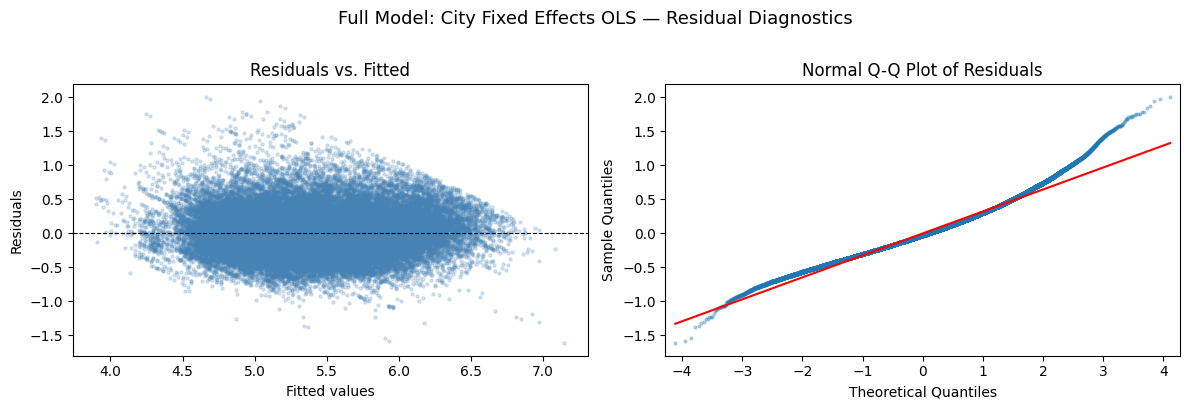

In [9]:
# --- Full Model: City Fixed Effects OLS ---

# City 1 (Amsterdam) dropped as reference category.
# All other specifications identical to Naive OLS.

X_full_const = sm.add_constant(X_processed)
model_full = sm.OLS(y, X_full_const).fit()

# --- VIF ---
vif_full = pd.DataFrame({
    "Feature": all_feature_cols,
    "VIF": [variance_inflation_factor(X_full_const.values, i) for i in range(1, X_full_const.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

# --- Residual diagnostics ---
fitted_full = model_full.fittedvalues
residuals_full = model_full.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted_full, residuals_full, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

sm.qqplot(residuals_full, line="s", ax=axes[1], alpha=0.3, markersize=2)
axes[1].set_title("Normal Q-Q Plot of Residuals")

plt.suptitle("Full Model: City Fixed Effects OLS — Residual Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("plots/section3_PlotDiagnostics2_cityFixedEffectsOLS.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
print("=== CITY FIXED EFFECTS OLS MODEL COEFFICIENTS ===")
print(model_full.summary().tables[1])

=== CITY FIXED EFFECTS OLS MODEL COEFFICIENTS ===
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          5.5480      0.019    294.757      0.000       5.511       5.585
cleanliness_rating             0.0372      0.002     18.019      0.000       0.033       0.041
guest_satisfaction_overall     0.0053      0.002      2.536      0.011       0.001       0.009
person_capacity                0.1141      0.002     55.862      0.000       0.110       0.118
bedrooms                       0.0768      0.002     43.007      0.000       0.073       0.080
dist                          -0.0538      0.002    -21.569      0.000      -0.059      -0.049
metro_dist                    -0.0169      0.002     -9.072      0.000      -0.021      -0.013
attr_index                     0.0806      0.003     28.162      0.000       0.075       0.086


In [11]:
print("=== CITY FIXED EFFECTS OLS MODEL VARIANCE INFLATION FACTORS ===\n")
vif_full

=== CITY FIXED EFFECTS OLS MODEL VARIANCE INFLATION FACTORS ===



,Feature,VIF
0,room_type_private,33.941027
1,room_type_apt,33.534862
2,city_London,5.982500
3,city_Rome,5.971312
4,rest_index,5.329073
5,city_Paris,4.508016
6,attr_index,4.015537
7,city_Lisbon,3.845803
8,city_Athens,3.650371
9,dist,3.048718


In [12]:
# --- Model comparison: Naive OLS vs. City Fixed Effects OLS ---
print("=== MODEL COMPARISON ===\n")
print(f"{'Metric':<25} {'Naive OLS':>12} {'City FE OLS':>13}")
print("-" * 52)
print(f"{'R²':<25} {model_naive.rsquared:>12.4f} {model_full.rsquared:>13.4f}")
print(f"{'Adj. R²':<25} {model_naive.rsquared_adj:>12.4f} {model_full.rsquared_adj:>13.4f}")
print(f"{'RMSE':<25} {np.sqrt(model_naive.mse_resid):>12.4f} {np.sqrt(model_full.mse_resid):>13.4f}")
print(f"{'AIC':<25} {model_naive.aic:>12.2f} {model_full.aic:>13.2f}")
print(f"{'BIC':<25} {model_naive.bic:>12.2f} {model_full.bic:>13.2f}")
print(f"{'F-statistic':<25} {model_naive.fvalue:>12.2f} {model_full.fvalue:>13.2f}")
print(f"{'# predictors':<25} {len(naive_feature_cols):>12d} {len(all_feature_cols):>13d}")


=== MODEL COMPARISON ===

Metric                       Naive OLS   City FE OLS
----------------------------------------------------
R²                              0.2863        0.6672
Adj. R²                         0.2861        0.6671
RMSE                            0.4734        0.3233
AIC                           68720.15      29680.51
BIC                           68852.80      29892.75
F-statistic                    1466.38       4460.49
# predictors                        14            23
